In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset
admission_df = pd.read_csv('College_admission.csv')

# Display first 5 rows
admission_df.head()

,admit,gre,gpa,ses,Gender_Male,Race,rank
0,0,380,3.61,1,0,3,3
1,1,660,3.67,2,0,2,3
2,1,800,4.00,2,0,2,1
3,1,640,3.19,1,1,2,4
4,0,520,2.93,3,1,2,4


In [3]:
# Shape of dataset
print("Dataset Shape:", admission_df.shape)

# Dataset Information
admission_df.info()

Dataset Shape: (400, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   admit        400 non-null    int64  
 1   gre          400 non-null    int64  
 2   gpa          400 non-null    float64
 3   ses          400 non-null    int64  
 4   Gender_Male  400 non-null    int64  
 5   Race         400 non-null    int64  
 6   rank         400 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 22.0 KB


In [4]:
# Missing values
admission_df.isnull().sum()

admit          0
gre            0
gpa            0
ses            0
Gender_Male    0
Race           0
rank           0
dtype: int64

In [5]:
# Statistical Summary
admission_df.describe()

,admit,gre,gpa,ses,Gender_Male,Race,rank
count,400.000000,400.000000,400.000000,400.000000,400.000,400.000000,400.00000
mean,0.317500,587.700000,3.389900,1.992500,0.475,1.962500,2.48500
std,0.466087,115.516536,0.380567,0.808751,0.500,0.823279,0.94446
min,0.000000,220.000000,2.260000,1.000000,0.000,1.000000,1.00000
25%,0.000000,520.000000,3.130000,1.000000,0.000,1.000000,2.00000
50%,0.000000,580.000000,3.395000,2.000000,0.000,2.000000,2.00000
75%,1.000000,660.000000,3.670000,3.000000,1.000,3.000000,3.00000
max,1.000000,800.000000,4.000000,3.000000,1.000,3.000000,4.00000


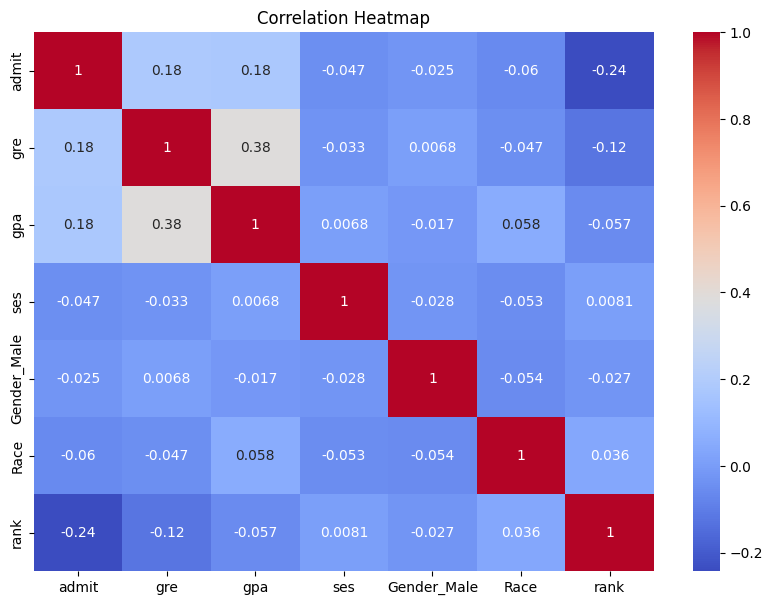

In [6]:
plt.figure(figsize=(10,7))
sns.heatmap(admission_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

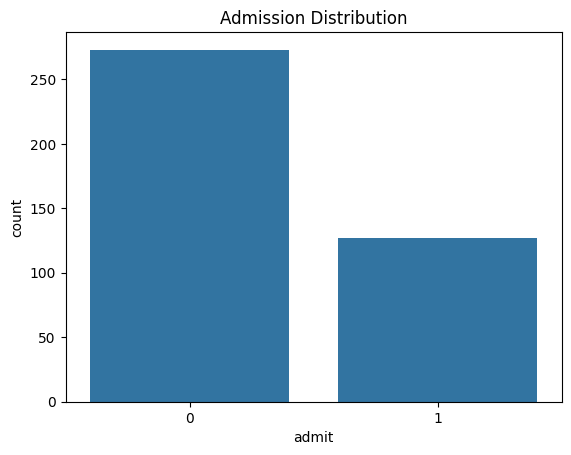

In [7]:
sns.countplot(x='admit', data=admission_df)
plt.title('Admission Distribution')
plt.show()

#This graph shows how many students received admission versus rejection.

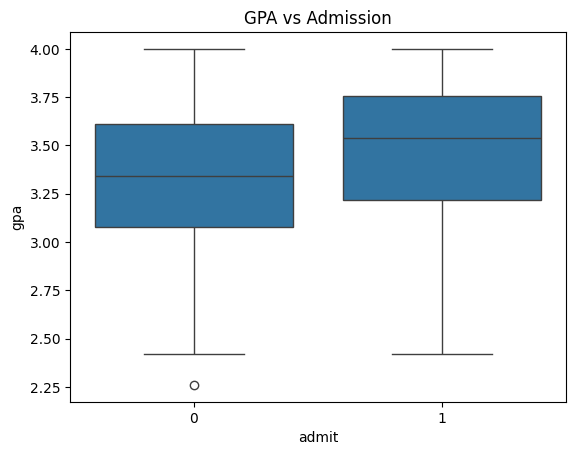

In [8]:
# GPA vs Admission

sns.boxplot(x='admit', y='gpa', data=admission_df)
plt.title('GPA vs Admission')
plt.show()

- Students with higher GPA generally have better admission chances.

- This proves GPA is an important feature.

### Feature Engineering

In [9]:
admission_df['gre_gpa_interaction'] = admission_df['gre'] * admission_df['gpa']

In [ ]:
#Students with both high GRE and high GPA may have significantly better admission chances.
# This helps the model understand combined academic performance.

In [10]:
# Create GPA Category
admission_df['high_gpa'] = np.where(admission_df['gpa'] >= 3.5, 1, 0)

### Define Features and Target

In [11]:
X = admission_df.drop('admit', axis=1)
y = admission_df['admit']

In [12]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Baseline Model – Logistic Regression

In [14]:
baseline_model = LogisticRegression()
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)

In [ ]:
# Baseline Model Evaluation

In [15]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1 Score:", baseline_f1)

Baseline Accuracy: 0.725
Baseline Precision: 0.7142857142857143
Baseline Recall: 0.2
Baseline F1 Score: 0.3125


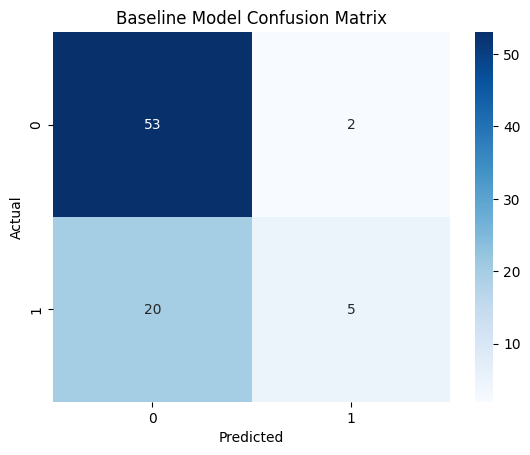

In [16]:
cm = confusion_matrix(y_test, baseline_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Advanced Model – Random Forest

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [ ]:
Random Forest:

Uses multiple decision trees
Reduces overfitting
Captures non-linear relationships
# It learns complex patterns better than Logistic Regression.

In [19]:
# Random Forest Evaluationrf_accuracy = accuracy_score(y_test, rf_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1 Score:", rf_f1)

Random Forest Accuracy: 0.7125
Random Forest Precision: 0.625
Random Forest Recall: 0.2
Random Forest F1 Score: 0.30303030303030304


In [20]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)
# Academic performance remains the strongest predictor of admission.

               Feature  Importance
6  gre_gpa_interaction    0.259173
1                  gpa    0.234000
0                  gre    0.179032
5                 rank    0.120810
4                 Race    0.065541
2                  ses    0.063222
3          Gender_Male    0.047012
7             high_gpa    0.031209


### Visualize Feature Importance

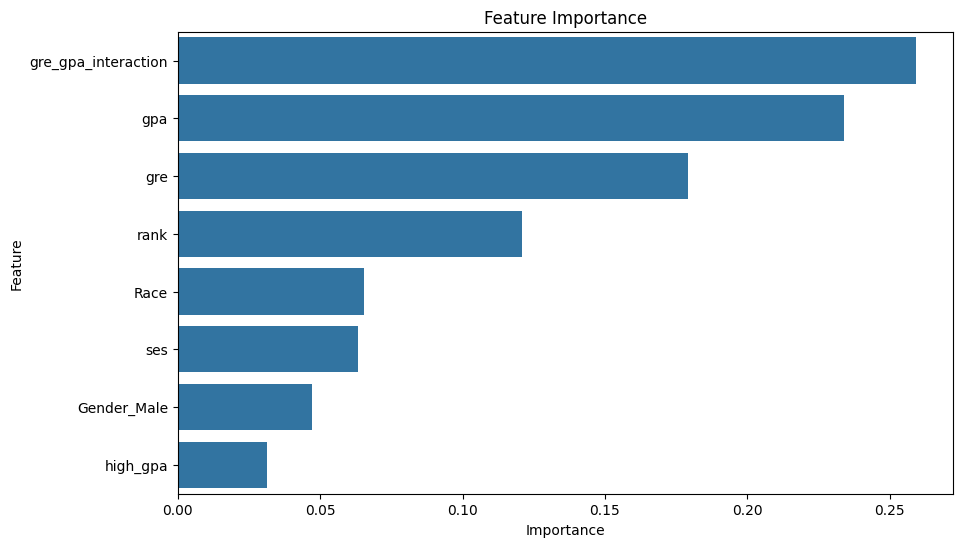

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()
# Visualization makes it easier to identify dominant factors affecting admission.

In [22]:
# Advanced Model – Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

In [23]:
# Gradient Boosting Evaluation
gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_precision = precision_score(y_test, gb_predictions)
gb_recall = recall_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions)

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Gradient Boosting Precision:", gb_precision)
print("Gradient Boosting Recall:", gb_recall)
print("Gradient Boosting F1 Score:", gb_f1)

Gradient Boosting Accuracy: 0.6875
Gradient Boosting Precision: 0.5
Gradient Boosting Recall: 0.36
Gradient Boosting F1 Score: 0.4186046511627907
